# Time Series Exploratory Analysis with Tesla Stock Data

## Project Overview

This notebook demonstrates fundamental time-series analysis techniques using historical Tesla stock market data.

The analysis covers date-time indexing, time-based filtering, resampling, aggregation, rolling statistics, cumulative moving averages, and exponentially weighted moving averages.

The objective is to understand how time-series data can be transformed and summarized across different time frequencies before applying forecasting models such as ARIMA and SARIMAX.

## Topics Covered

- Downloading financial time-series data
- Understanding a `DatetimeIndex`
- Date-based filtering and slicing
- Annual, quarterly, business-period, and monthly resampling
- Time-based aggregation
- Simple moving averages
- Cumulative moving averages
- Exponential moving averages
- Exponentially weighted moving averages

## Environment Setup

The required packages are installed for retrieving, manipulating, and visualizing time-series data.

- `pandas-datareader` provides interfaces for accessing online financial data sources.
- `yfinance` retrieves historical market data from Yahoo Finance.
- Python's built-in `datetime` module is used for date and time operations.

> Package installation is generally performed once per environment. These commands can be removed or commented out after the dependencies have been installed.

In [4]:
!pip install pandas-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 4.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas-datareader]pandas-datareader]


In [18]:
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 7.4 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]3/5 [curl_cffi]


## Import Required Libraries

The following libraries are imported for:

- Retrieving financial market data
- Manipulating time-series datasets
- Working with dates and times
- Creating visualizations

In [254]:
import pandas_datareader as pdr
import pandas as pd
from datetime import datetime
import yfinance 
import matplotlib.pyplot as plt
%matplotlib inline

## Download Historical Tesla Stock Data

Historical Tesla stock data is downloaded from Yahoo Finance.

The dataset includes:

- Open price
- High price
- Low price
- Closing price
- Trading volume

The observation date is stored as the dataframe index, making the dataset suitable for time-based filtering, resampling, and rolling-window analysis.

Because Yahoo Finance data changes over time, the exact start date, end date, and number of observations may differ whenever this notebook is rerun.

In [255]:
df=yfinance.download('TSLA',period='15y')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2011-05-31,2.009333,2.018667,1.970000,1.979333,49357500
2011-06-01,1.901333,2.006667,1.892000,2.000000,22948500
2011-06-02,1.917333,1.954667,1.900667,1.901333,14794500
2011-06-03,2.008667,2.100000,1.966667,1.996667,93138000
2011-06-06,1.913333,2.008667,1.884000,2.006667,34966500


## Initial Data Inspection

The first and last observations, dataset dimensions, and available variables are reviewed to understand the structure and coverage of the downloaded time series.

In [256]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2026-05-22,426.010010,431.510010,420.510010,422.670013,46104700
2026-05-26,433.589996,435.200012,426.119995,430.260010,45658900
2026-05-27,440.359985,445.600006,435.519989,442.890015,44656500
2026-05-28,442.100006,443.959991,436.299988,437.619995,32435000
2026-05-29,435.790009,441.070007,428.140015,439.850006,45059400


In [257]:
df.shape

(3772, 5)

## Visualize the Historical Time Series

The available stock market variables are plotted across time to obtain an initial view of long-term price movement and trading activity.

This broad visualization helps identify:

- Long-term growth or decline
- Periods of high volatility
- Changes in trading activity
- Potential structural shifts

<Axes: xlabel='Date'>

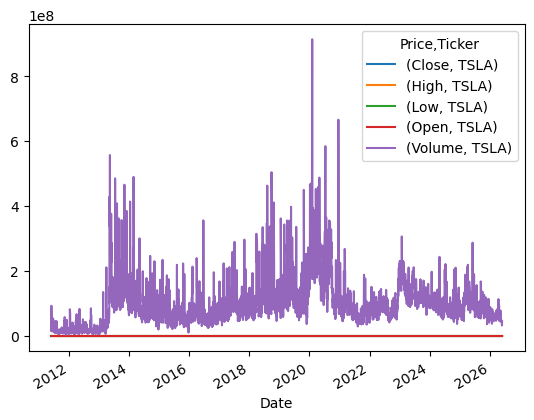

In [258]:
df.plot()

### Trading Volume over Time

Trading volume represents the number of Tesla shares traded during each market session.

Large changes in volume may indicate periods of increased investor attention, market uncertainty, significant news, or major price movement.

<Axes: xlabel='Date'>

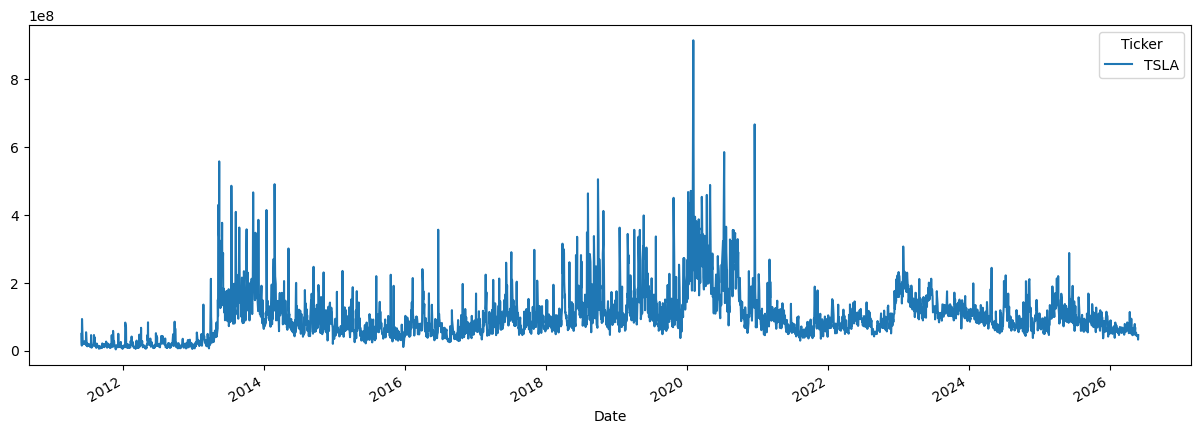

In [259]:
df['Volume'].plot(figsize=(15,5))

## Time-Based Filtering and Plot Customization

A smaller date range is selected to examine a particular period more closely.

The plots demonstrate how to:

- Restrict the displayed date range with `xlim`
- Restrict the displayed value range with `ylim`
- Modify line style
- Customize line color
- Focus on a specific market period

Filtering is particularly useful when the complete time series contains many years of observations.

<Axes: xlabel='Date'>

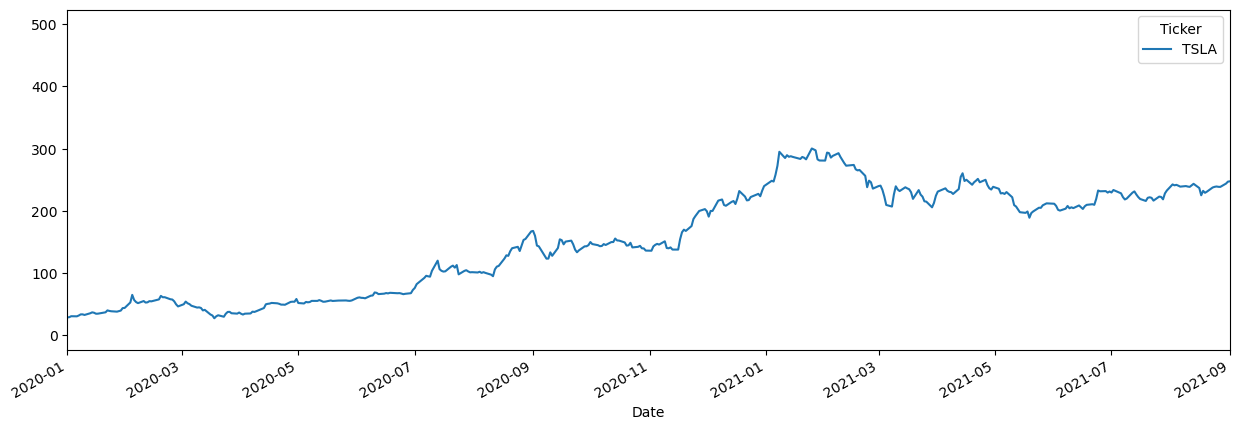

In [261]:
df['High'].plot(xlim=['2020-01-01','2021-09-01'],figsize=(15,5))

In [262]:
#Specifiying range for xlim, ylim

<Axes: xlabel='Date'>

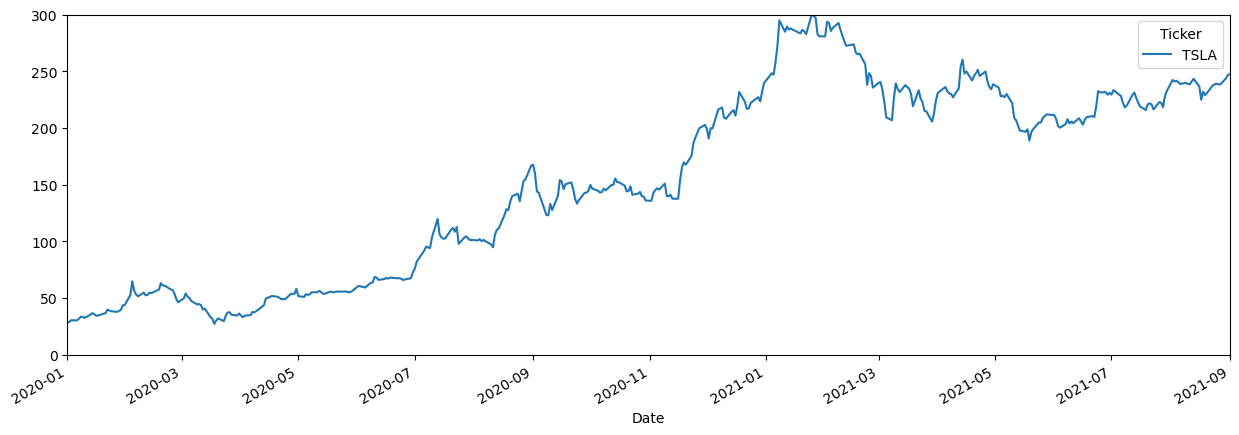

In [263]:
df['High'].plot(xlim=['2020-01-01','2021-09-01'],ylim=[0,300],figsize=(15,5))

In [264]:
#xlim, ylim, coloring, line style

<Axes: xlabel='Date'>

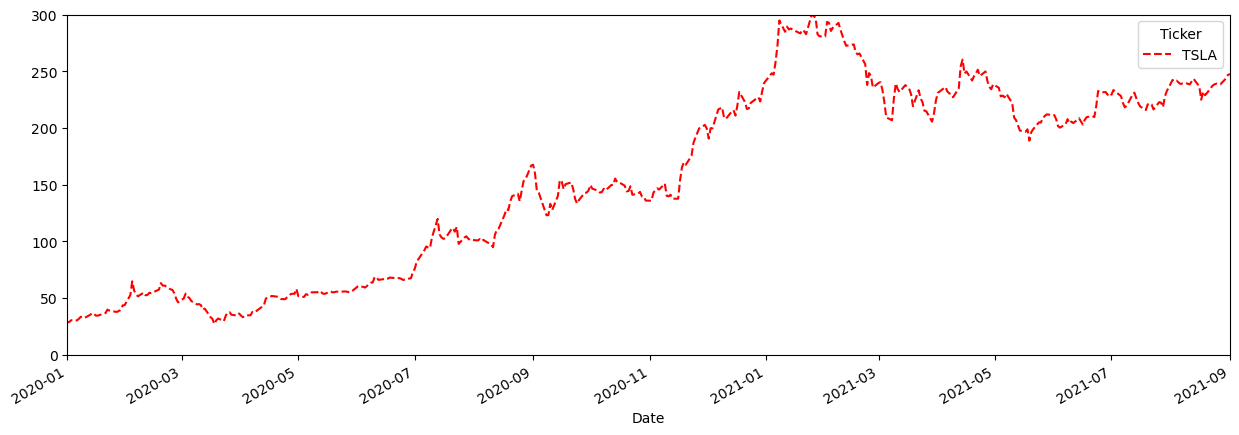

In [265]:
df['High'].plot(xlim=['2020-01-01','2021-09-01'],ylim=[0,300],figsize=(15,5),ls='--',c='red')

In [266]:
df.index

DatetimeIndex(['2011-05-31', '2011-06-01', '2011-06-02', '2011-06-03',
               '2011-06-06', '2011-06-07', '2011-06-08', '2011-06-09',
               '2011-06-10', '2011-06-13',
               ...
               '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20',
               '2026-05-21', '2026-05-22', '2026-05-26', '2026-05-27',
               '2026-05-28', '2026-05-29'],
              dtype='datetime64[ns]', name='Date', length=3772, freq=None)

In [267]:
index=df.loc['2020-01-01':'2021-09-01'].index
index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2021-08-19', '2021-08-20', '2021-08-23', '2021-08-24',
               '2021-08-25', '2021-08-26', '2021-08-27', '2021-08-30',
               '2021-08-31', '2021-09-01'],
              dtype='datetime64[ns]', name='Date', length=421, freq=None)

In [268]:
share_open=df.loc['2020-01-01':'2021-09-01']['Open']
share_open

Ticker,TSLA
Date,
2020-01-02,28.299999
2020-01-03,29.366667
2020-01-06,29.364668
2020-01-07,30.760000
2020-01-08,31.580000
...,...
2021-08-26,236.103333
2021-08-27,235.000000
2021-08-30,238.240005


In [269]:
## DataTime Index

In [270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3772 entries, 2011-05-31 to 2026-05-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   3772 non-null   float64
 1   (High, TSLA)    3772 non-null   float64
 2   (Low, TSLA)     3772 non-null   float64
 3   (Open, TSLA)    3772 non-null   float64
 4   (Volume, TSLA)  3772 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 305.9 KB


In [271]:
df.reset_index().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        3772 non-null   datetime64[ns]
 1   (Close, TSLA)   3772 non-null   float64       
 2   (High, TSLA)    3772 non-null   float64       
 3   (Low, TSLA)     3772 non-null   float64       
 4   (Open, TSLA)    3772 non-null   float64       
 5   (Volume, TSLA)  3772 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 176.9 KB


In [272]:
# we are already having datetime column indexed and also date column is of datetime format 

In [273]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2011-05-31,2.009333,2.018667,1.970000,1.979333,49357500
2011-06-01,1.901333,2.006667,1.892000,2.000000,22948500
2011-06-02,1.917333,1.954667,1.900667,1.901333,14794500
2011-06-03,2.008667,2.100000,1.966667,1.996667,93138000
2011-06-06,1.913333,2.008667,1.884000,2.006667,34966500


In [274]:
#Date Function

In [275]:
datetime.now()

datetime.datetime(2026, 5, 30, 16, 1, 13, 725946)

In [276]:
dt=datetime(2015,1,1)
dt

datetime.datetime(2015, 1, 1, 0, 0)

In [277]:
dt.date()

datetime.date(2015, 1, 1)

In [278]:
dt.day

1

In [279]:
dt.weekday()

3

In [280]:
dt.year

2015

In [281]:
dt.hour

0

In [282]:
dt.month

1

In [283]:
#Time Resampling

In [284]:
df.resample(rule='A')

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/4040819757.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A')


In [285]:
df.resample(rule='A').min()

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/2153198699.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').min()


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2011-12-31,1.463333,1.540667,1.433333,1.462000,3594000
2012-12-31,1.519333,1.790000,1.509333,1.774667,5473500
2013-12-31,2.194000,2.225333,2.140667,2.205333,6603000
2014-12-31,9.289333,9.800000,9.111333,9.366667,19983000
2015-12-31,12.333333,12.619333,12.093333,12.388667,10620000
2016-12-31,9.578000,10.331333,9.403333,9.488000,24892500
2017-12-31,14.466000,14.688667,14.064000,14.316667,32800500
2018-12-31,16.704000,17.355333,16.306000,16.851999,46210500


In [286]:
#Rule A - Year & Frequency - for a year frequency (min, max)
df.resample(rule='A').max()

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/580562448.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').max()


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2011-12-31,2.329333,2.333333,2.268667,2.308667,93138000
2012-12-31,2.534000,2.663333,2.474000,2.546000,85206000
2013-12-31,12.891333,12.966667,12.558000,12.930667,557458500
2014-12-31,19.069332,19.427999,18.693333,19.177999,490225500
2015-12-31,18.817333,19.110001,18.420000,18.680000,234744000
2016-12-31,17.694668,17.955999,16.967333,17.763332,356136000
2017-12-31,25.666668,25.974001,25.290001,25.779333,296871000
2018-12-31,25.304667,25.830667,24.474667,25.000000,504745500


/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/3644064767.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').max()['Open'].plot()


<Axes: xlabel='Date'>

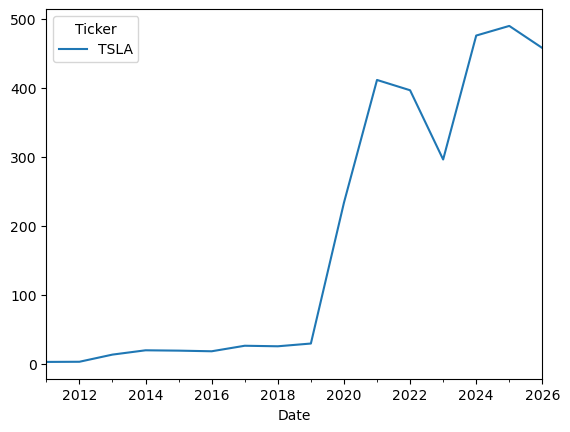

In [287]:
df.resample(rule='A').max()['Open'].plot()

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/1864782303.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').max()['Volume'].plot()


<Axes: xlabel='Date'>

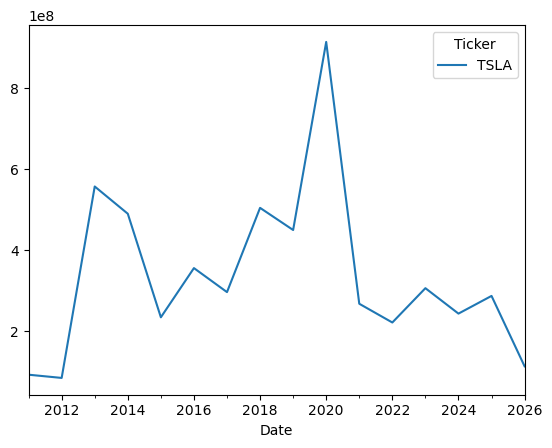

In [288]:
df.resample(rule='A').max()['Volume'].plot()

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/3458275414.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').max()['High'].plot()


<Axes: xlabel='Date'>

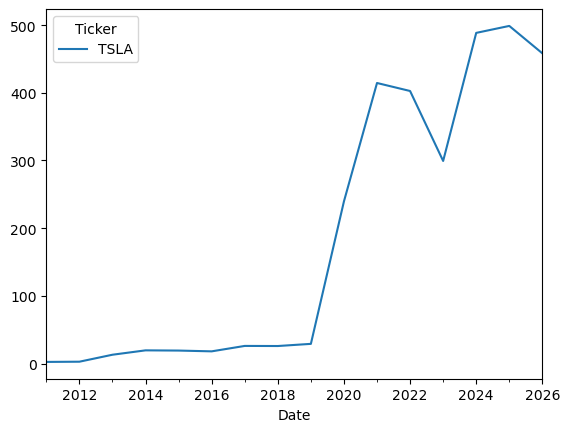

In [289]:
df.resample(rule='A').max()['High'].plot()

<Axes: xlabel='Date'>

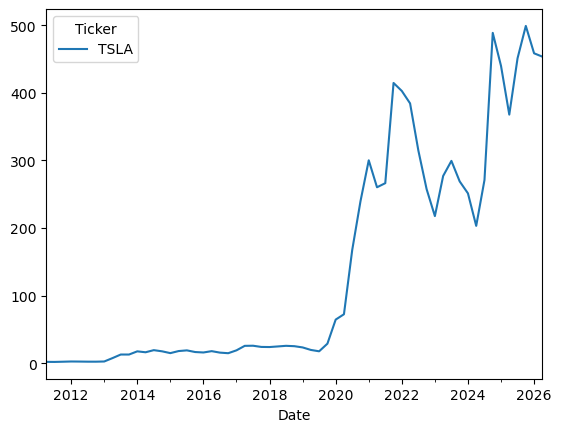

In [290]:
#Quaterly frequency - quater start frequency
df.resample(rule='QS').max()['High'].plot()

In [291]:
#Business Year End Frequency
df.resample(rule='BA').max()['Close']

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/3505907731.py:2: FutureWarning: 'BA' is deprecated and will be removed in a future version, please use 'BYE' instead.
  df.resample(rule='BA').max()['Close']


Ticker,TSLA
Date,
2011-12-30,2.329333
2012-12-31,2.534000
2013-12-31,12.891333
2014-12-31,19.069332
2015-12-31,18.817333
2016-12-30,17.694668
2017-12-29,25.666668
2018-12-31,25.304667
2019-12-31,28.729334


/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/4092478215.py:1: FutureWarning: 'BA' is deprecated and will be removed in a future version, please use 'BYE' instead.
  df.resample(rule='BA').max()['Close'].plot()


<Axes: xlabel='Date'>

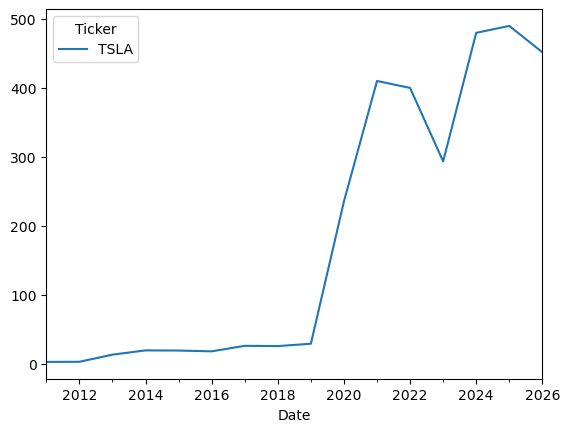

In [292]:
df.resample(rule='BA').max()['Close'].plot()

<Axes: xlabel='Date'>

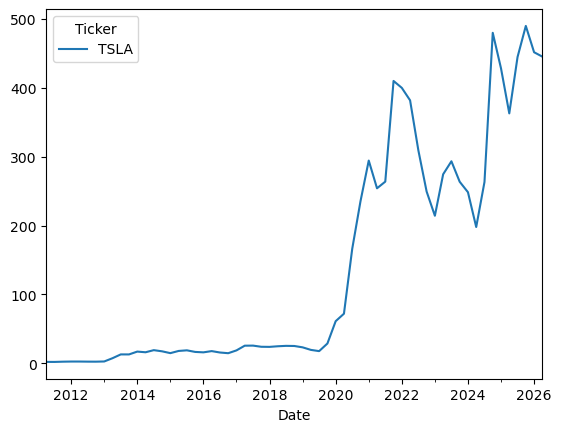

In [293]:
#Business quaterly Frequency
df.resample(rule='BQS').max()['Close'].plot()

In [294]:
#Plotting

In [295]:
df['Open'].resample(rule='BA').mean()

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/2471066023.py:1: FutureWarning: 'BA' is deprecated and will be removed in a future version, please use 'BYE' instead.
  df['Open'].resample(rule='BA').mean()


Ticker,TSLA
Date,
2011-12-30,1.857022
2012-12-31,2.080208
2013-12-31,6.961095
2014-12-31,14.894360
2015-12-31,15.322130
2016-12-30,14.003897
2017-12-29,20.953081
2018-12-31,21.145564
2019-12-31,18.201876


/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/3566823603.py:1: FutureWarning: 'BA' is deprecated and will be removed in a future version, please use 'BYE' instead.
  df['Open'].resample(rule='BA').mean().plot(kind='bar')


<Axes: xlabel='Date'>

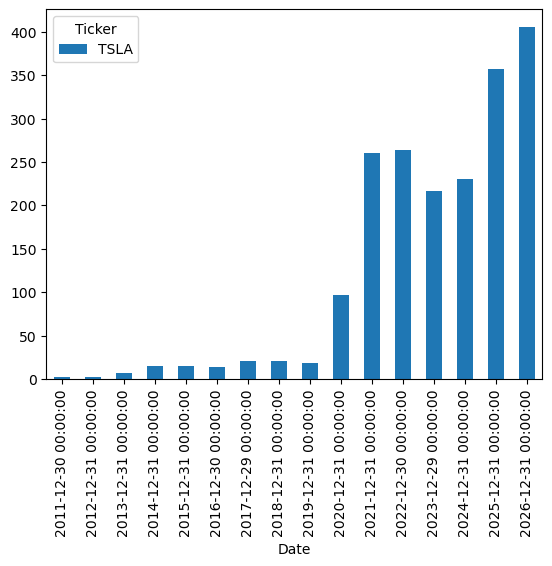

In [296]:
df['Open'].resample(rule='BA').mean().plot(kind='bar')

In [297]:
df['Open'].resample(rule='A').mean()

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/4035554798.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df['Open'].resample(rule='A').mean()


Ticker,TSLA
Date,
2011-12-31,1.857022
2012-12-31,2.080208
2013-12-31,6.961095
2014-12-31,14.894360
2015-12-31,15.322130
2016-12-31,14.003897
2017-12-31,20.953081
2018-12-31,21.145564
2019-12-31,18.201876


/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/1445318596.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df['Open'].resample(rule='A').mean().plot(kind='bar')


<Axes: xlabel='Date'>

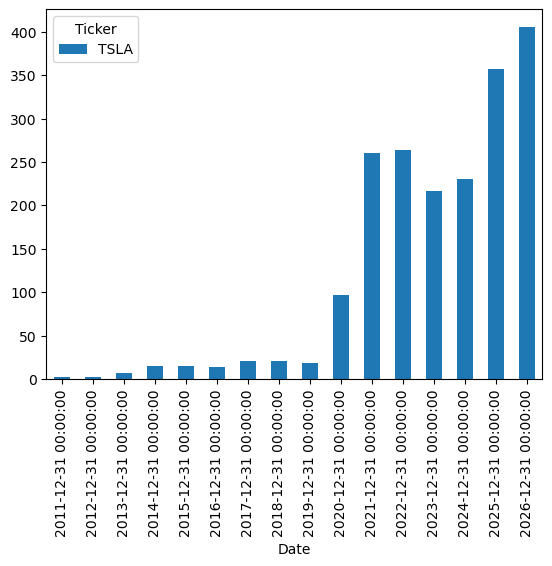

In [298]:
df['Open'].resample(rule='A').mean().plot(kind='bar')

In [299]:
#Monthly

In [300]:
df['Open'].resample(rule='M').max()

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/383701629.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['Open'].resample(rule='M').max()


Ticker,TSLA
Date,
2011-05-31,1.979333
2011-06-30,2.006667
2011-07-31,1.992667
2011-08-31,1.912667
2011-09-30,1.768000
...,...
2026-01-31,457.799988
2026-02-28,430.299988
2026-03-31,405.179993


/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_31322/1512206294.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.loc['2020-01-01':'2021-09-01', 'Open'].resample('M').max().plot(kind='bar', figsize=(15,6))


<Axes: xlabel='Date'>

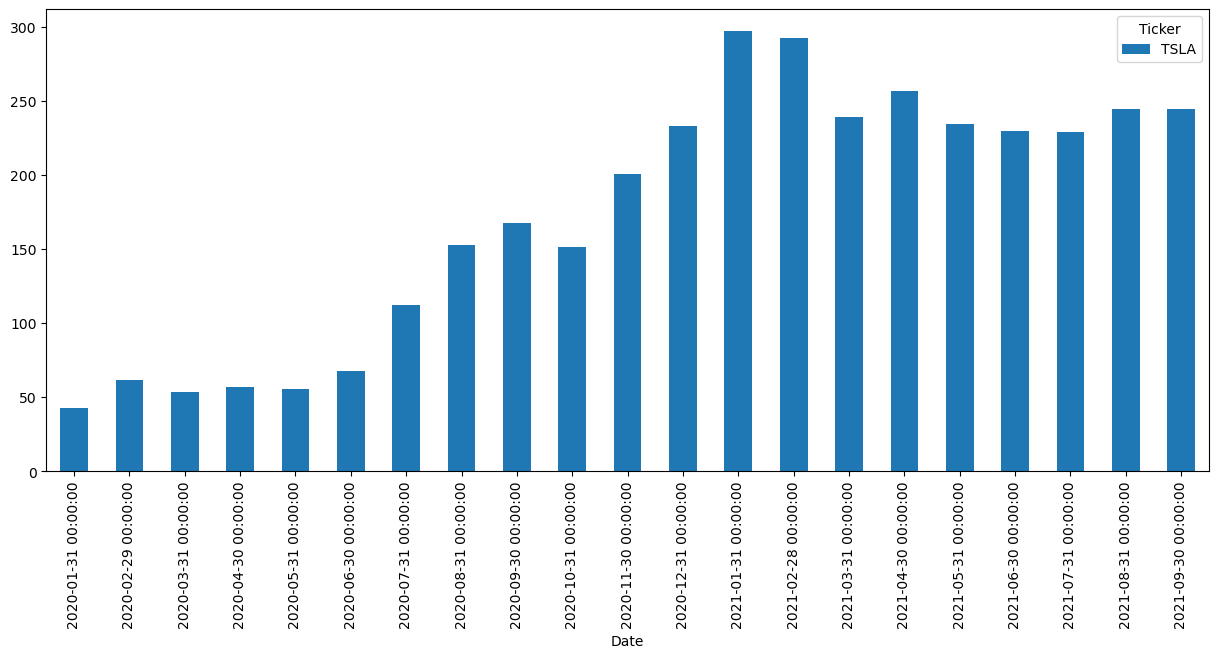

In [301]:

df.loc['2020-01-01':'2021-09-01', 'Open'].resample('M').max().plot(kind='bar', figsize=(15,6))

In [302]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2026-05-22,426.010010,431.510010,420.510010,422.670013,46104700
2026-05-26,433.589996,435.200012,426.119995,430.260010,45658900
2026-05-27,440.359985,445.600006,435.519989,442.890015,44656500
2026-05-28,442.100006,443.959991,436.299988,437.619995,32435000
2026-05-29,435.790009,441.070007,428.140015,439.850006,45059400


In [303]:
#Aggregate 

In [304]:
#Rolling Window or moving Average

In [305]:
df['High'].rolling(3)

Rolling [window=3,center=False,axis=0,method=single]

In [306]:
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2011-05-31,2.009333,2.018667,1.970000,1.979333,49357500
2011-06-01,1.901333,2.006667,1.892000,2.000000,22948500
2011-06-02,1.917333,1.954667,1.900667,1.901333,14794500
2011-06-03,2.008667,2.100000,1.966667,1.996667,93138000
2011-06-06,1.913333,2.008667,1.884000,2.006667,34966500
2011-06-07,1.891333,1.959333,1.884000,1.929333,18331500
2011-06-08,1.808000,1.906667,1.801333,1.896000,25438500
2011-06-09,1.841333,1.873333,1.806667,1.828667,24048000


In [307]:
df['High'].rolling(3).mean()

Ticker,TSLA
Date,
2011-05-31,NaN
2011-06-01,NaN
2011-06-02,1.993334
2011-06-03,2.020445
2011-06-06,2.021111
...,...
2026-05-22,425.306671
2026-05-26,431.220011
2026-05-27,437.436676


In [308]:
df['Open:30 days rolling']=df['Open'].rolling(30).mean()

In [309]:
df.tail()

Price,Close,High,Low,Open,Volume,Open:30 days rolling
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2026-05-22,426.010010,431.510010,420.510010,422.670013,46104700,397.495335
2026-05-26,433.589996,435.200012,426.119995,430.260010,45658900,400.168335
2026-05-27,440.359985,445.600006,435.519989,442.890015,44656500,403.009002
2026-05-28,442.100006,443.959991,436.299988,437.619995,32435000,405.368669
2026-05-29,435.790009,441.070007,428.140015,439.850006,45059400,406.903336


<Axes: xlabel='Date'>

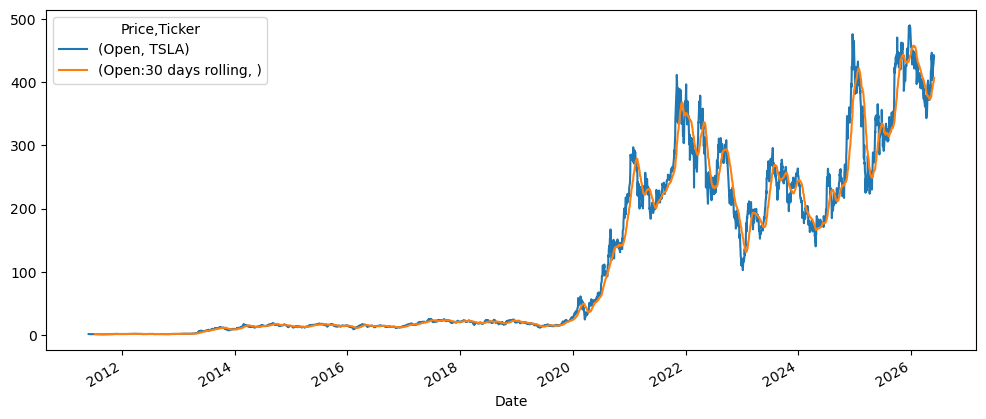

In [310]:
df[['Open','Open:30 days rolling']].plot(figsize=(12,5))

In [311]:
df['Open:10 days rolling']=df['Open'].rolling(window=10, min_periods=1).mean()

In [312]:
df.head(5)

Price,Close,High,Low,Open,Volume,Open:30 days rolling,Open:10 days rolling
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,
Date,,,,,,,
2011-05-31,2.009333,2.018667,1.970000,1.979333,49357500,NaN,1.979333
2011-06-01,1.901333,2.006667,1.892000,2.000000,22948500,NaN,1.989667
2011-06-02,1.917333,1.954667,1.900667,1.901333,14794500,NaN,1.960222
2011-06-03,2.008667,2.100000,1.966667,1.996667,93138000,NaN,1.969333
2011-06-06,1.913333,2.008667,1.884000,2.006667,34966500,NaN,1.976800


<Axes: xlabel='Date'>

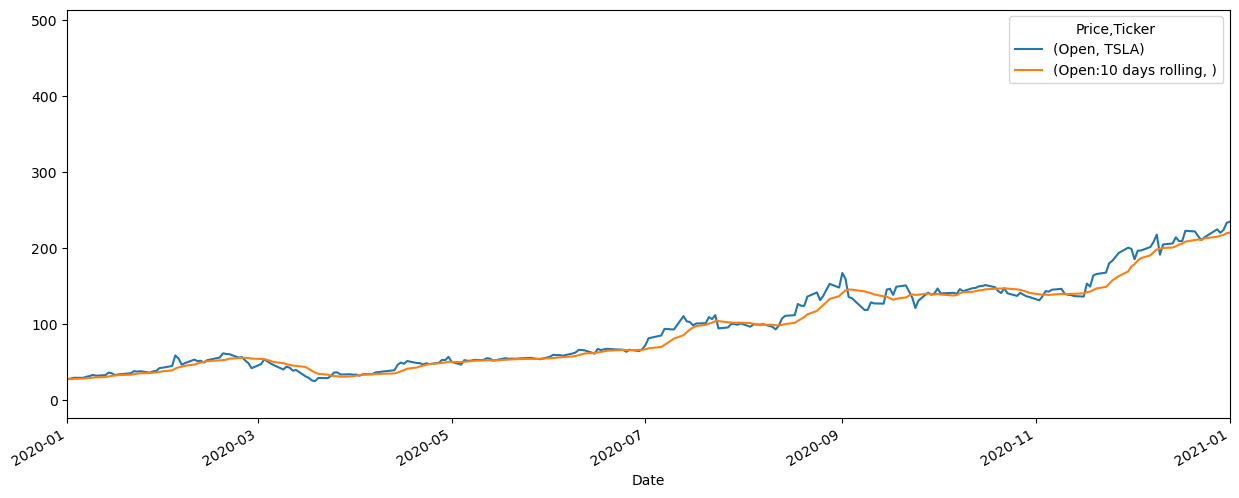

In [314]:
df[['Open','Open:10 days rolling']].plot(figsize=(15,6),xlim=['2020-01-01','2021-01-01'])

In [315]:
df['Open:30 days rolling']=df['Open'].rolling(window=30, min_periods=1).mean()
df['Open:50 days rolling']=df['Open'].rolling(window=50, min_periods=1).mean()

In [316]:
df.tail()

Price,Close,High,Low,Open,Volume,Open:30 days rolling,Open:10 days rolling,Open:50 days rolling
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,
Date,,,,,,,,
2026-05-22,426.010010,431.510010,420.510010,422.670013,46104700,NaN,425.559003,388.109001
2026-05-26,433.589996,435.200012,426.119995,430.260010,45658900,NaN,426.369003,388.730801
2026-05-27,440.359985,445.600006,435.519989,442.890015,44656500,NaN,426.517004,389.664202
2026-05-28,442.100006,443.959991,436.299988,437.619995,32435000,NaN,426.612003,390.502802
2026-05-29,435.790009,441.070007,428.140015,439.850006,45059400,NaN,425.948004,391.319802


<Axes: xlabel='Date'>

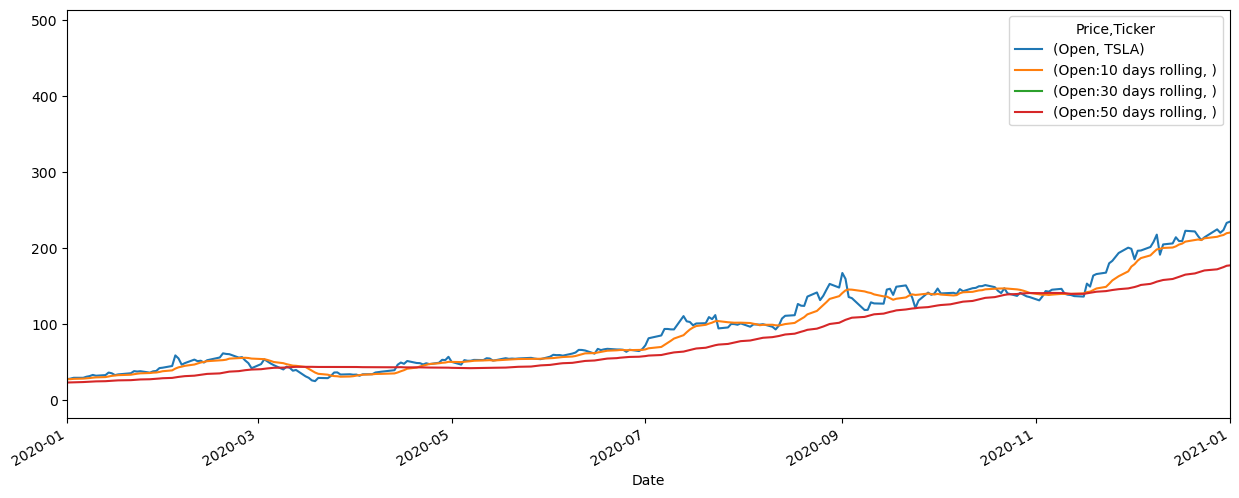

In [317]:
df[['Open','Open:10 days rolling','Open:30 days rolling','Open:50 days rolling']].plot(figsize=(15,6),xlim=['2020-01-01','2021-01-01'])

In [318]:
# Cummulative Moving Average - expanding

In [324]:
df['Open'].expanding().mean()

Ticker,TSLA
Date,
2011-05-31,1.979333
2011-06-01,1.989667
2011-06-02,1.960222
2011-06-03,1.969333
2011-06-06,1.976800
...,...
2026-05-22,113.131635
2026-05-26,113.215777
2026-05-27,113.303223


<Axes: xlabel='Date'>

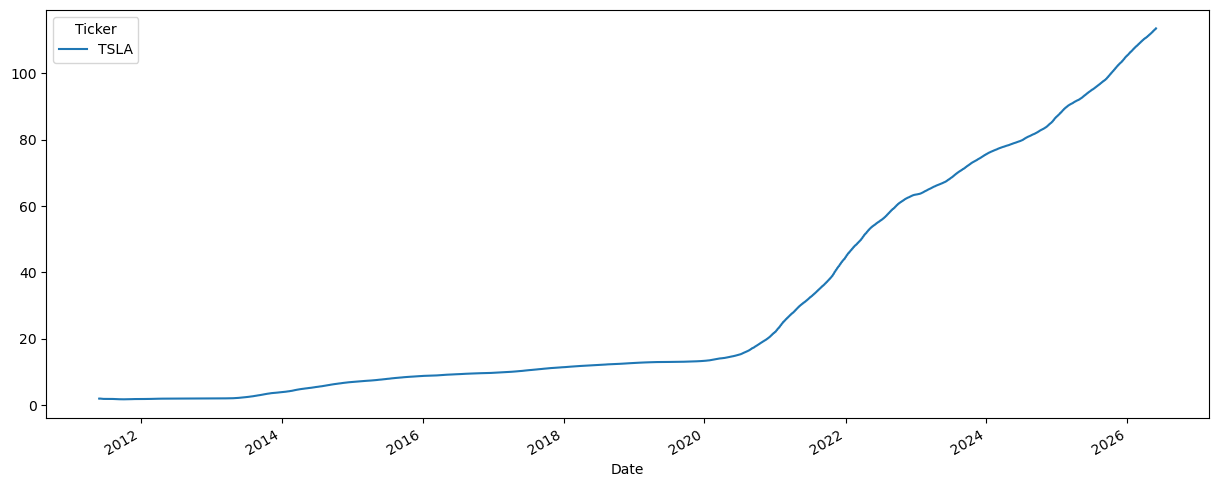

In [323]:
df['Open'].expanding().mean().plot(figsize=(15,6))

In [326]:
#EMA - Exponential Moving Average 

In [327]:
df['EMA_0.1']=df['Open'].ewm(alpha=0.1).mean()

In [328]:
df.head()

Price,Close,High,Low,Open,Volume,Open:30 days rolling,Open:10 days rolling,Open:50 days rolling,EMA_0.1
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,
Date,,,,,,,,,
2011-05-31,2.009333,2.018667,1.970000,1.979333,49357500,NaN,1.979333,1.979333,1.979333
2011-06-01,1.901333,2.006667,1.892000,2.000000,22948500,NaN,1.989667,1.989667,1.990210
2011-06-02,1.917333,1.954667,1.900667,1.901333,14794500,NaN,1.960222,1.960222,1.957414
2011-06-03,2.008667,2.100000,1.966667,1.996667,93138000,NaN,1.969333,1.969333,1.968828
2011-06-06,1.913333,2.008667,1.884000,2.006667,34966500,NaN,1.976800,1.976800,1.978068


<Axes: xlabel='Date'>

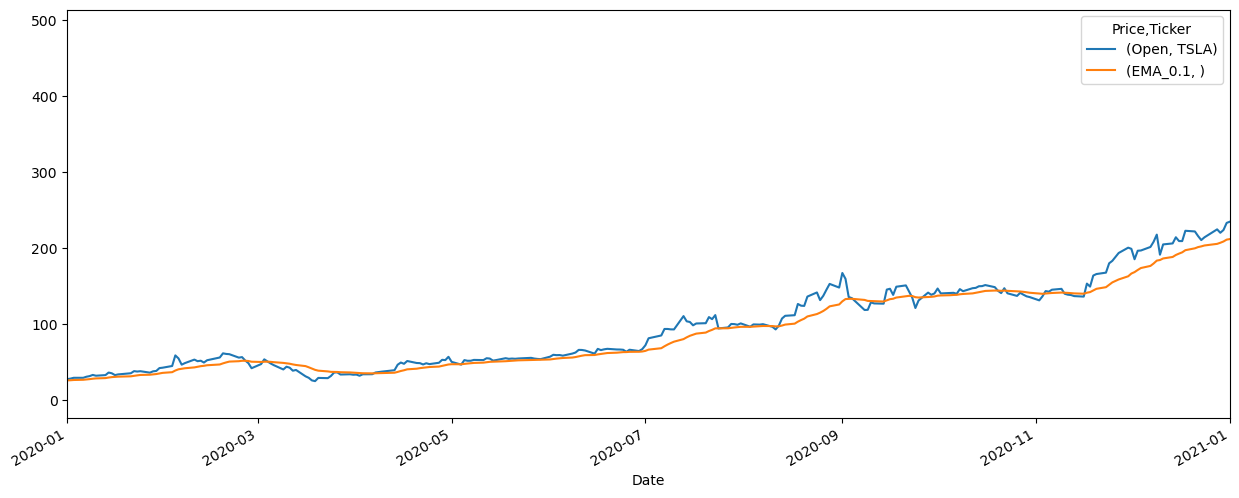

In [329]:
df[['Open','EMA_0.1']].plot(figsize=(15,6),xlim=['2020-01-01','2021-01-01'])

In [330]:
df['EMA_0.3']=df['Open'].ewm(alpha=0.3).mean()

<Axes: xlabel='Date'>

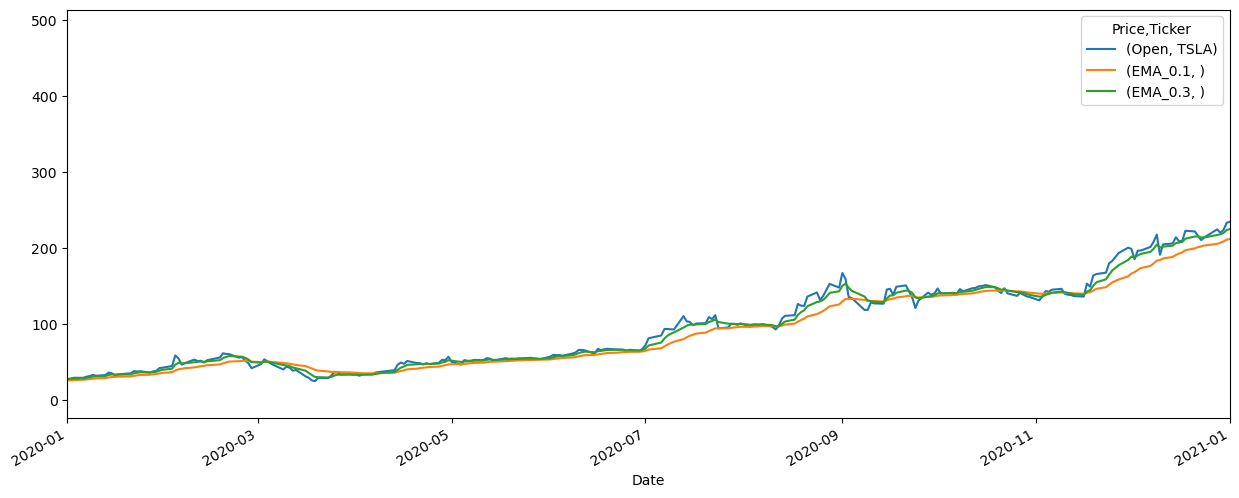

In [331]:
df[['Open','EMA_0.1', 'EMA_0.3']].plot(figsize=(15,6),xlim=['2020-01-01','2021-01-01'])

In [325]:
#EWMA - Exponential Weighted Moving Average - EWMA implemented using ewm(span) - span gives the number of days

In [332]:
df['EWMA_5_days']=df['Open'].ewm(span=5).mean()

<Axes: xlabel='Date'>

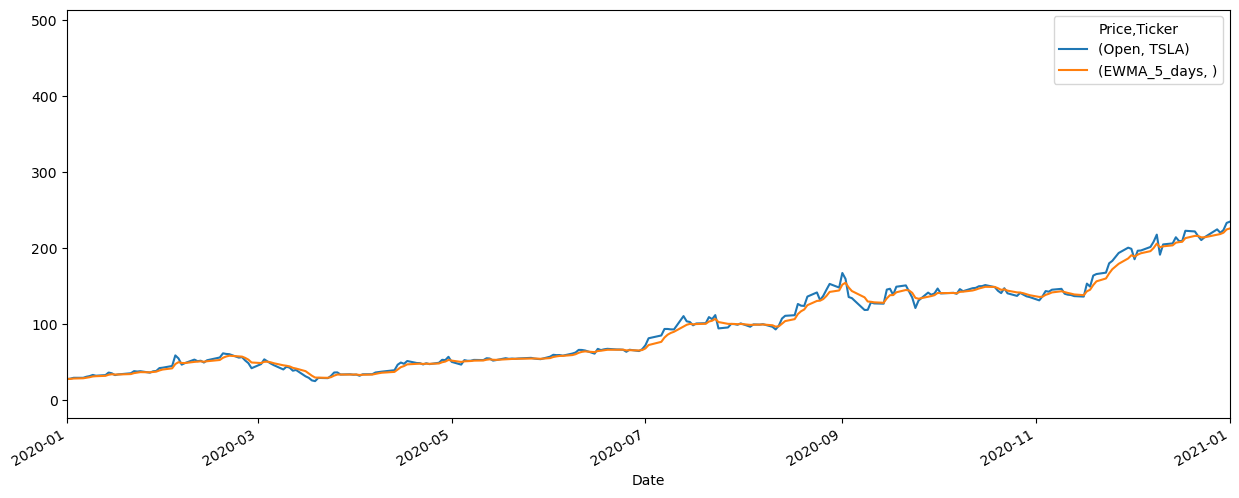

In [333]:
df[['Open','EWMA_5_days']].plot(figsize=(15,6),xlim=['2020-01-01','2021-01-01'])

<Axes: xlabel='Date'>

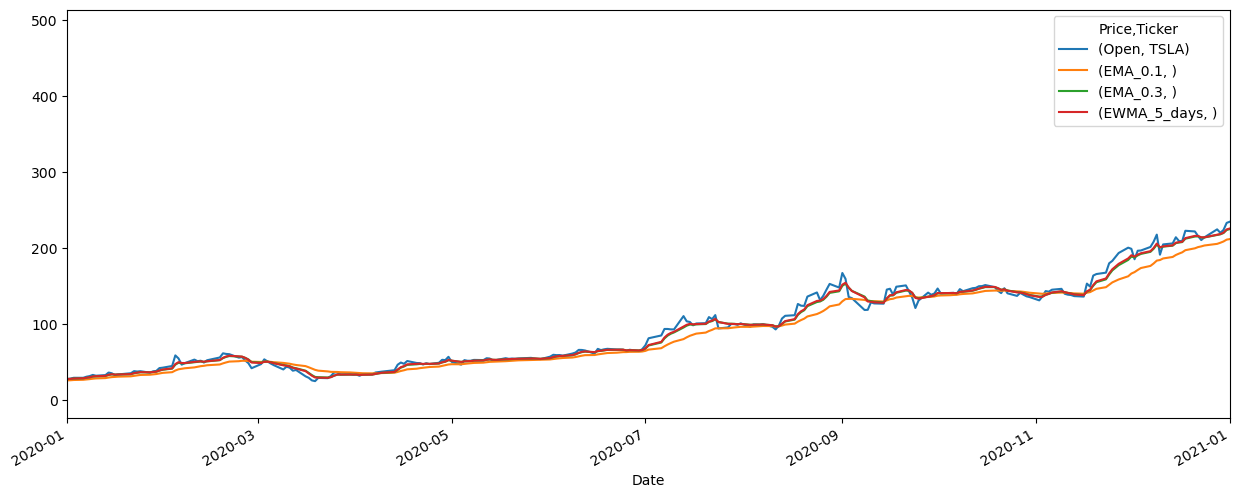

In [334]:
df[['Open','EMA_0.1', 'EMA_0.3','EWMA_5_days']].plot(figsize=(15,6),xlim=['2020-01-01','2021-01-01'])